# VKR — полная визуализация результатов

Этот ноутбук строит **все** графики и таблицы по всем датасетам и методам:
- сводные таблицы (loss / accuracy / wall-clock),
- bar-comparison,
- кривые сходимости по 3 осям X (time, full evals, epochs-equivalent),
- Critical Difference Diagram по объединённым датасетам и отдельно по HPO,
- разрезы по группам датасетов (малые / большие).

Запускайте ячейки сверху вниз. Графики автоматически сохраняются в `results_fixed/`.

## 1. Импорты

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from src.aggregation import aggregate_results, print_table
from src.plots import (
    plot_convergence_all_axes, plot_convergence_unified,
    plot_bar_comparison, plot_convergence,
)
from src.stats import run_full_statistical_analysis
from src.methods import HPO_METHODS, DE_METHODS

print("HPO методы:", list(HPO_METHODS.keys()))
print("DE методы:", list(DE_METHODS.keys()))

HPO методы: ['Adam_baseline', 'Adam_RandomSearch', 'Adam_TPE', 'Adam_GP_BO', 'Adam_Hyperband', 'Adam_BOHB', 'Adam_MFBO']
DE методы: ['Baseline_DE', 'Optuna_DE', 'DE_DE_Hybrid']


## 2. Агрегация всех результатов

In [2]:
df, hist, traj = aggregate_results()
print(f"Всего строк (dataset × method): {len(df)}")
print(f"Датасеты: {sorted(df['dataset'].unique())}")
print(f"Методы: {sorted(df['method'].unique())}")

Всего строк (dataset × method): 58
Датасеты: ['abalone', 'digits', 'higgs', 'kin8nm', 'wdbc', 'wine']
Методы: ['Adam_BOHB', 'Adam_GP_BO', 'Adam_Hyperband', 'Adam_MFBO', 'Adam_RandomSearch', 'Adam_TPE', 'Adam_baseline', 'Baseline_DE', 'DE_DE_Hybrid', 'Optuna_DE']


In [3]:
# Убираем дубликаты: оставляем строку с большим n_seeds
df = (df.sort_values('n_seeds', ascending=True)
              .drop_duplicates(subset=['dataset', 'method'], keep='last')
              .reset_index(drop=True))

## 3. Сводные таблицы (все датасеты, все методы)

Три таблицы: test-loss, accuracy/R², wall-clock. mean ± std по seeds.

In [4]:
print_table(df)


=== Test Loss (mean ± std по seeds) ===
╒═══════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│ Dataset   │ Adam_MFBO              │ Adam_BOHB              │ Adam_GP_BO             │ Adam_Hyperband         │ Adam_baseline          │ Adam_TPE               │ Adam_RandomSearch      │ Optuna_DE              │ DE_DE_Hybrid           │ Baseline_DE            │
╞═══════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ KIN8NM    │ 0.2262 ± 0.0835  (n=4) │ 0.1117 ± 0.0170  (n=4) │ 0.1041 ± 0.0027  (n=4) │ 0.1131 ± 0.0096  (n=4) │ 0.1081 ± 0.0057  (n=5) │ 0.1027 ± 0.0111  (n=5) │ 0.1

## 4. Bar comparison

Test-loss по всем датасетам и методам с error bars.

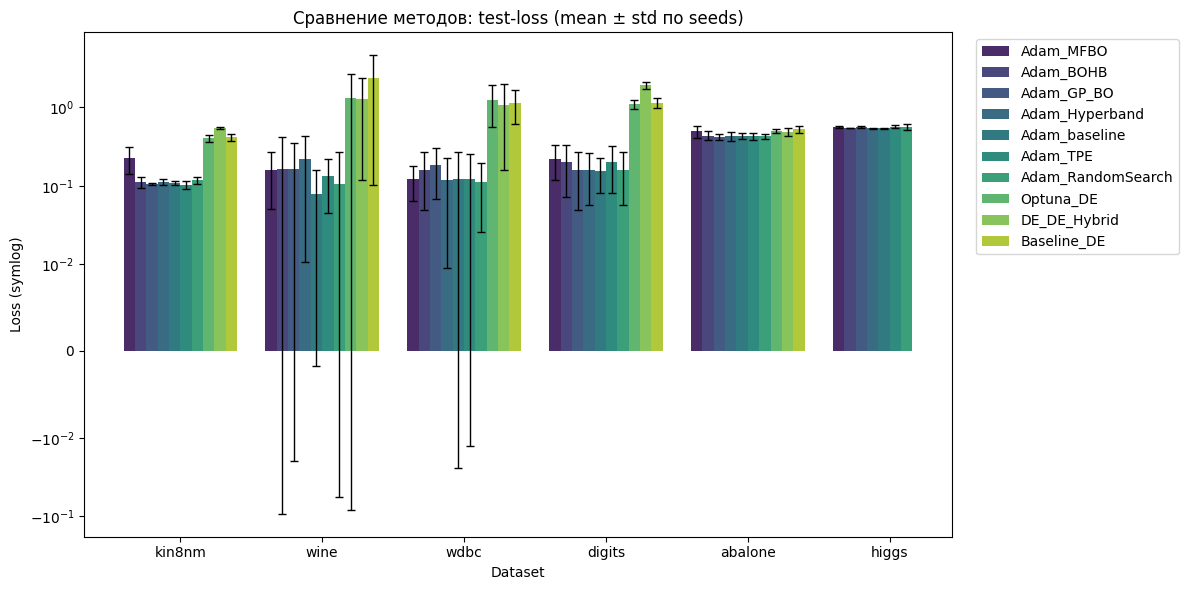

In [5]:
plot_bar_comparison(df, save=True)

## 5. Кривые сходимости по всем датасетам

Три рисунка: с осью X = wall-clock seconds / number of full-fidelity evals / epochs-equivalent.

⚠️ Ось "Number of full-fidelity evaluations" корректна только для MFBO (он один в течение прогона
делает несколько full-fidelity оценок). Остальные HPO-методы засчитывают n_evals_full=1
только в самом конце. В тексте диплома лучше использовать **wall-clock** и **epochs-equivalent**.

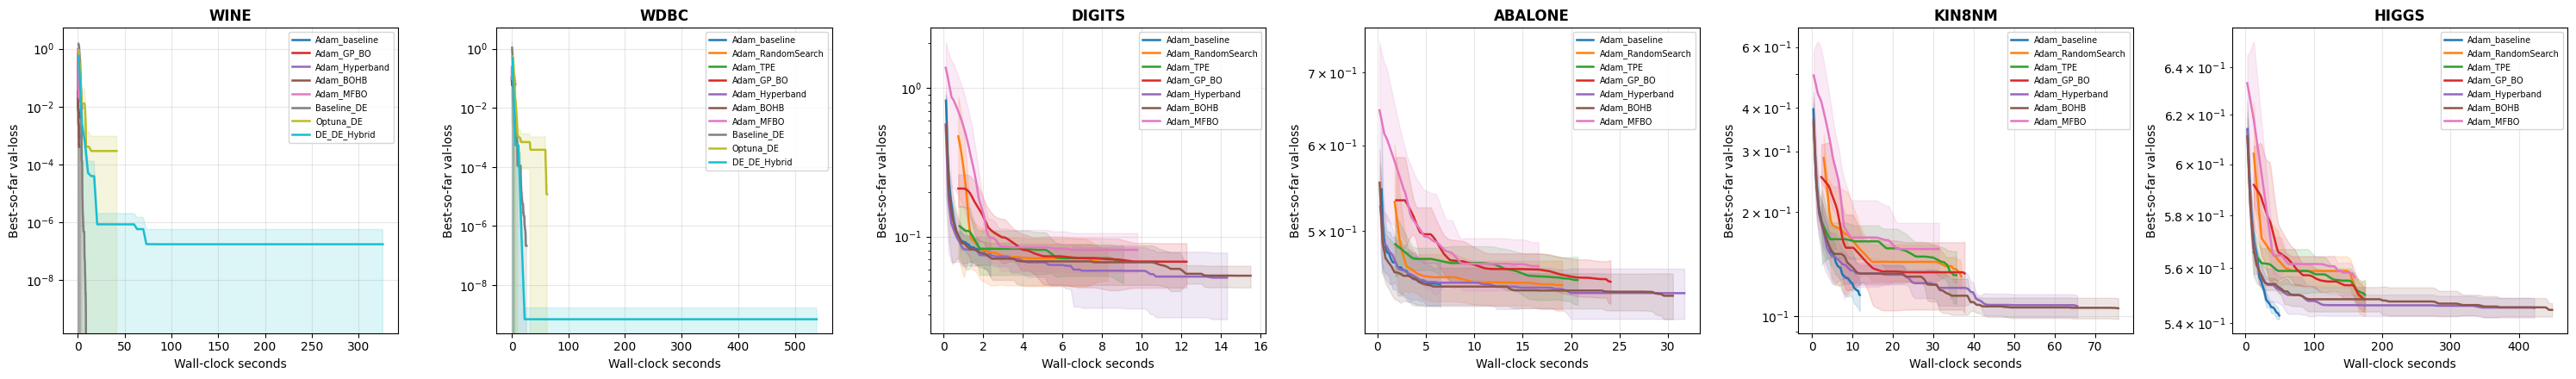

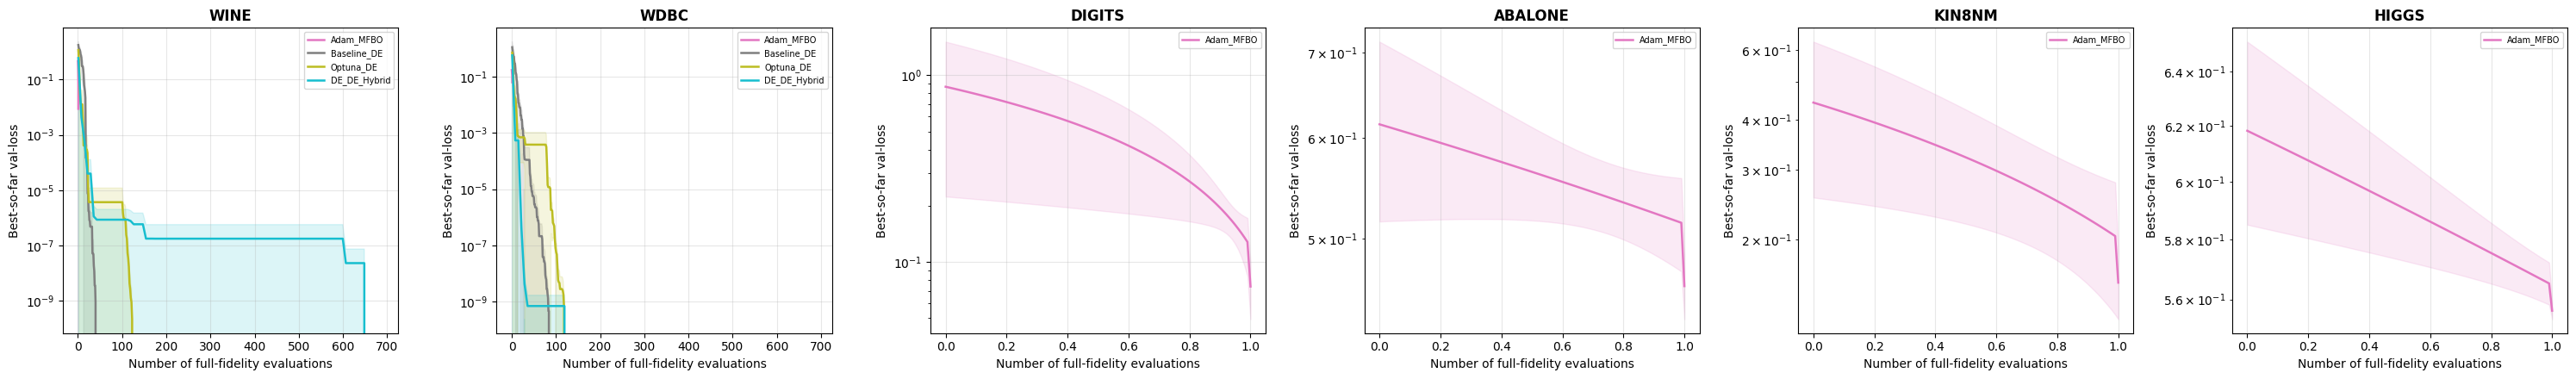

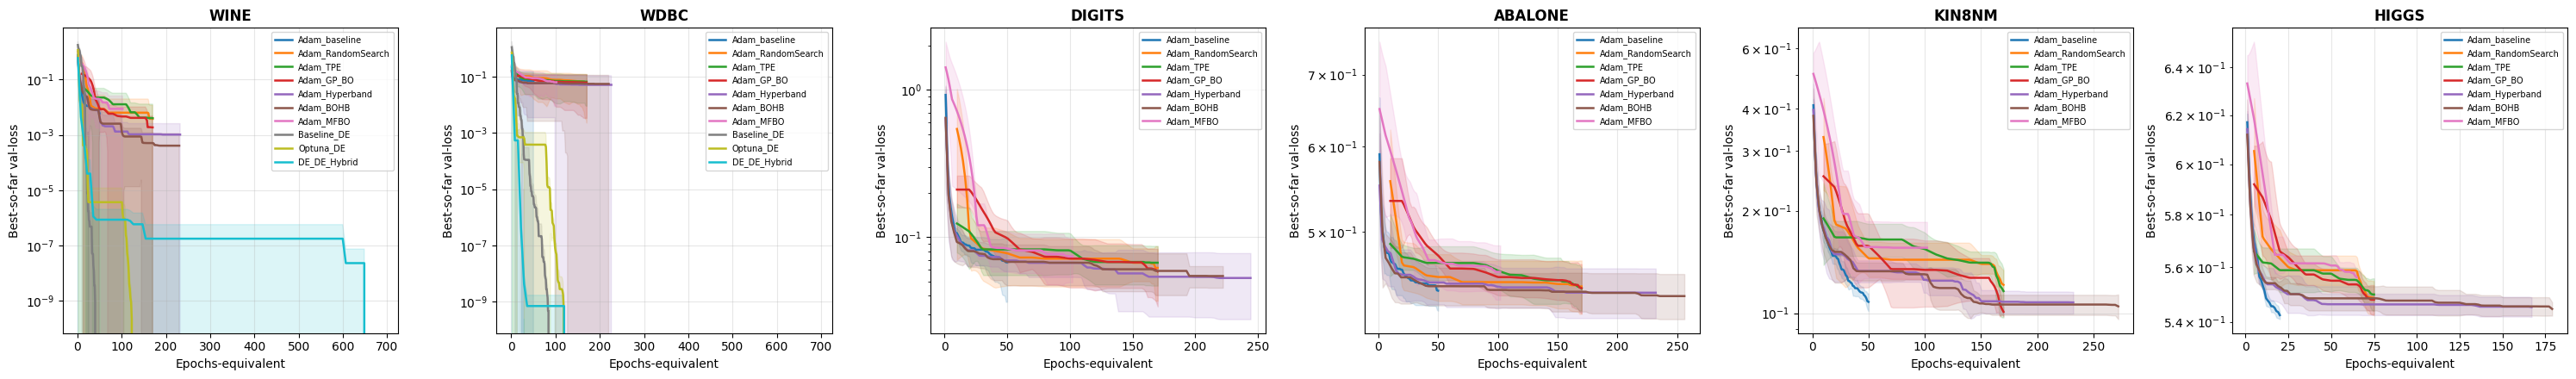

In [6]:
plot_convergence_all_axes(traj, save=True)

## 6. Кривые сходимости только по wall-clock

Это самая показательная ось для сравнения методов — измеряет реальную стоимость
вычислений и не зависит от методологии трекинга бюджета.

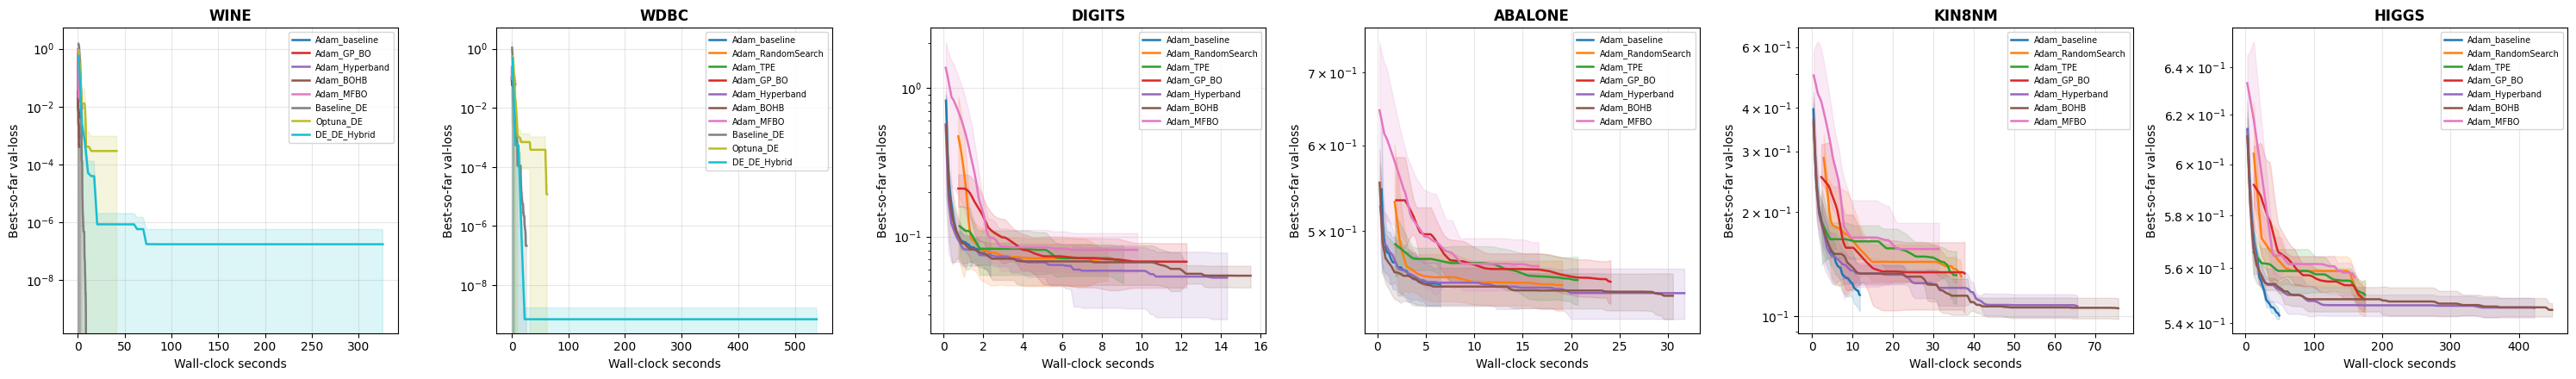

In [7]:
plot_convergence_unified(traj, x_key="time", save=True, save_name="convergence_time_all.png")

## 7. Кривые сходимости только по epochs-equivalent

Альтернативная "честная" ось: число пройденных по данным эпох (нормировано на compute).

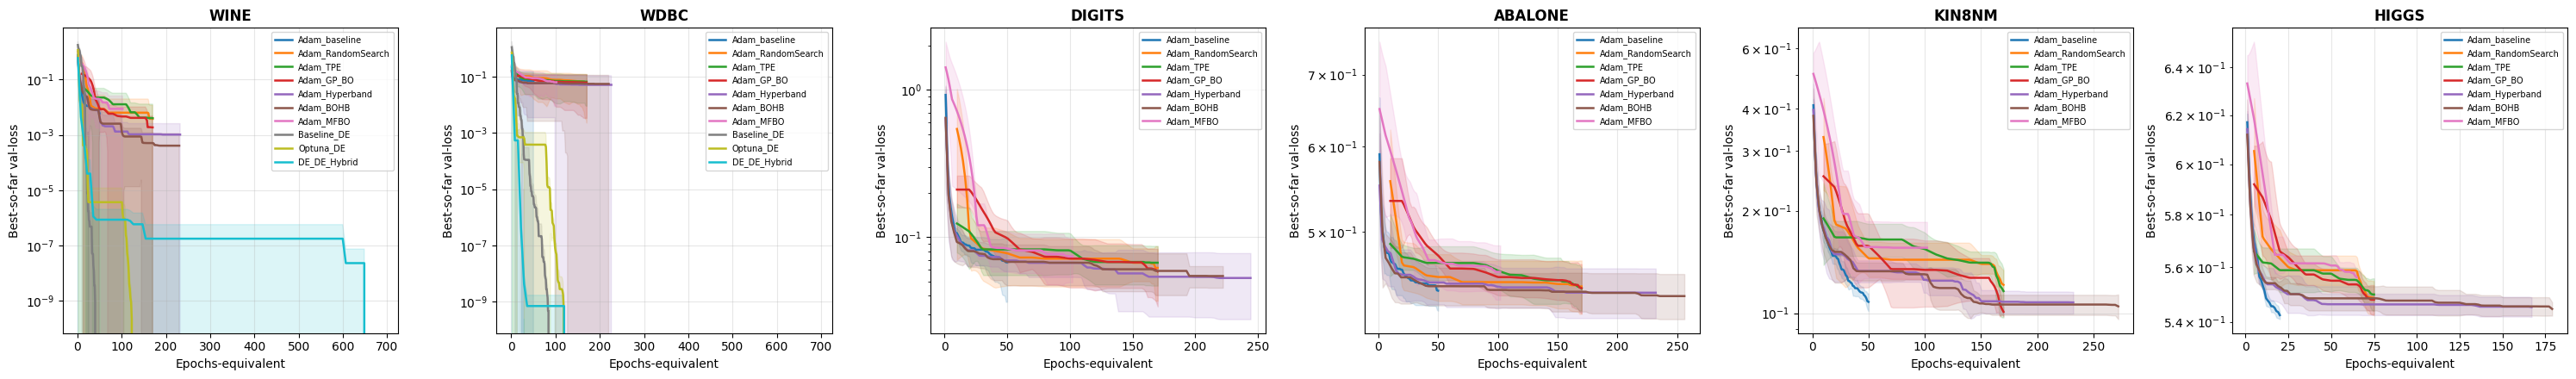

In [8]:
plot_convergence_unified(traj, x_key="n_epochs_eq", save=True,
                          save_name="convergence_epochs_all.png")

## 8. Critical Difference Diagram — по всем датасетам, все методы

**Главный статистический результат для диплома.** Friedman + Nemenyi
по 7 датасетам × 10 методам.

Ограничение: DE-методы запускались только на малых tabular (5 датасетов), поэтому
строки с N/A на higgs/fashion_mnist выпадут — `aggregate_results` исключает методы,
которые посчитаны не на всех датасетах. Если хочется включить DE — фильтруйте
по датасетам, где они есть (см. ячейку 11).

In [9]:
# import os
# RESULTS = 'results_fixed'
# for ds in os.listdir(RESULTS):
#     ds_path = os.path.join(RESULTS, ds)
#     old = os.path.join(ds_path, 'Adam_Optuna')
#     new = os.path.join(ds_path, 'Adam_TPE')
#     if os.path.isdir(old):
#         old_seeds = set(os.listdir(old))
#         new_seeds = set(os.listdir(new)) if os.path.isdir(new) else set()
#         print(f"{ds}: Adam_Optuna={sorted(old_seeds)}, Adam_TPE={sorted(new_seeds)}")
#         missing = old_seeds - new_seeds
#         if missing:
#             print(f"  ⚠ В Adam_TPE НЕ хватает: {missing} — НЕ удаляйте Adam_Optuna")
#         else:
#             print(f"  ✓ Adam_TPE покрывает все seeds — Adam_Optuna можно удалять")

In [10]:
# import os, shutil
# RESULTS = 'results_fixed'  # подставьте свой путь
# removed = 0
# for ds in os.listdir(RESULTS):
#     if ds == 'kin8nm':  # на kin8nm Adam_TPE неполный — оставляем Adam_Optuna
#         continue
#     old = os.path.join(RESULTS, ds, 'Adam_Optuna')
#     if os.path.isdir(old):
#         shutil.rmtree(old)
#         print(f"removed {old}")
#         removed += 1
# print(f"\nУдалено: {removed} папок Adam_Optuna")
# print(f"Осталась: kin8nm/Adam_Optuna (для seed_999, которого нет в Adam_TPE)")

In [11]:
# # Покажет ВСЕ дубликаты с указанием method и dataset
# dup_mask = df.duplicated(subset=['dataset', 'method'], keep=False)
# print(f"Дубликатов: {dup_mask.sum()}")
# if dup_mask.any():
#     dups = df[dup_mask].sort_values(['dataset', 'method'])
#     print(dups[['dataset', 'method', 'n_seeds', 'loss_mean']].to_string())

In [12]:
# print(f"Всего строк: {len(df)}")
# print(f"Уникальных пар (dataset, method): {df[['dataset', 'method']].drop_duplicates().shape[0]}")
# print()
# # Сколько раз каждый method встречается на каждом датасете
# counts = df.groupby(['dataset', 'method']).size().reset_index(name='count')
# print(counts[counts['count'] > 1].to_string())

=== Friedman test на матрице 6 датасетов × 7 методов ===
χ² = 7.2143, p-value = 0.3015
H0 не отвергается на уровне α=0.05: значимых различий нет

Средние ранги (1 = лучший):
method
Adam_baseline        2.666667
Adam_GP_BO           3.666667
Adam_TPE             3.666667
Adam_Hyperband       3.666667
Adam_RandomSearch    3.833333
Adam_BOHB            4.833333
Adam_MFBO            5.666667

Critical Difference (Nemenyi, α=0.05): 3.6780


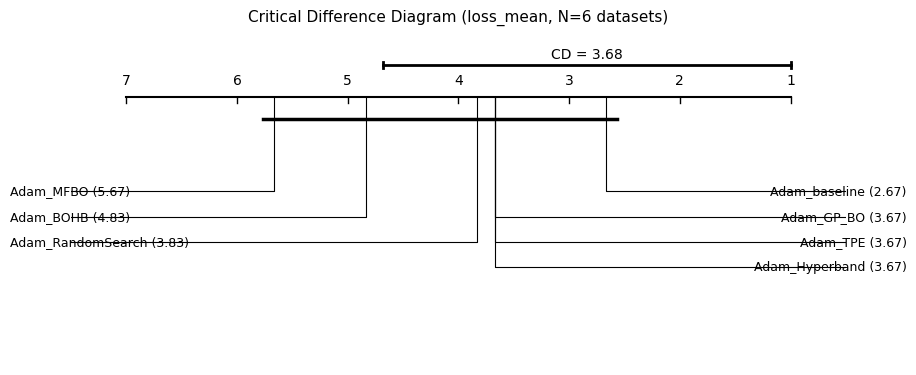

In [13]:
results_full = run_full_statistical_analysis(df, metric="loss_mean", lower_is_better=True)

## 9. Critical Difference Diagram — только HPO-методы

Без DE, по всем 7 датасетам. Это методологически чистое сравнение
методов одной парадигмы.

Только HPO: 42 строк
=== Friedman test на матрице 6 датасетов × 7 методов ===
χ² = 7.2143, p-value = 0.3015
H0 не отвергается на уровне α=0.05: значимых различий нет

Средние ранги (1 = лучший):
method
Adam_baseline        2.666667
Adam_GP_BO           3.666667
Adam_TPE             3.666667
Adam_Hyperband       3.666667
Adam_RandomSearch    3.833333
Adam_BOHB            4.833333
Adam_MFBO            5.666667

Critical Difference (Nemenyi, α=0.05): 3.6780


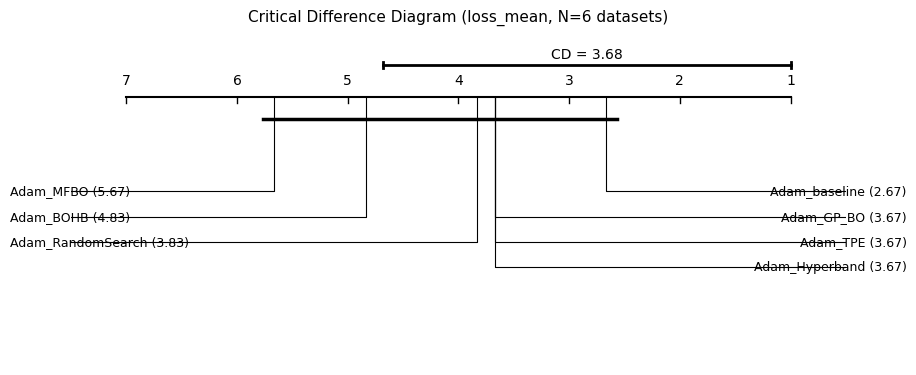

In [14]:
df_hpo = df[df["method"].isin(HPO_METHODS.keys())]
print(f"Только HPO: {len(df_hpo)} строк")
results_hpo = run_full_statistical_analysis(df_hpo, metric="loss_mean", lower_is_better=True)

## 10. Critical Difference Diagram — только малые датасеты, все 10 методов

Тут DE-методы есть на всех датасетах, поэтому участвуют в анализе.

Малые датасеты: 50 строк, методов: 10
=== Friedman test на матрице 5 датасетов × 10 методов ===
χ² = 32.0836, p-value = 0.0002
H0 отвергается на уровне α=0.05: между методами есть значимые различия

Средние ранги (1 = лучший):
method
Adam_baseline        3.0
Adam_TPE             3.0
Adam_RandomSearch    3.4
Adam_GP_BO           3.6
Adam_Hyperband       4.0
Adam_BOHB            5.2
Adam_MFBO            6.0
DE_DE_Hybrid         8.6
Optuna_DE            8.8
Baseline_DE          9.4

Critical Difference (Nemenyi, α=0.05): 6.0586


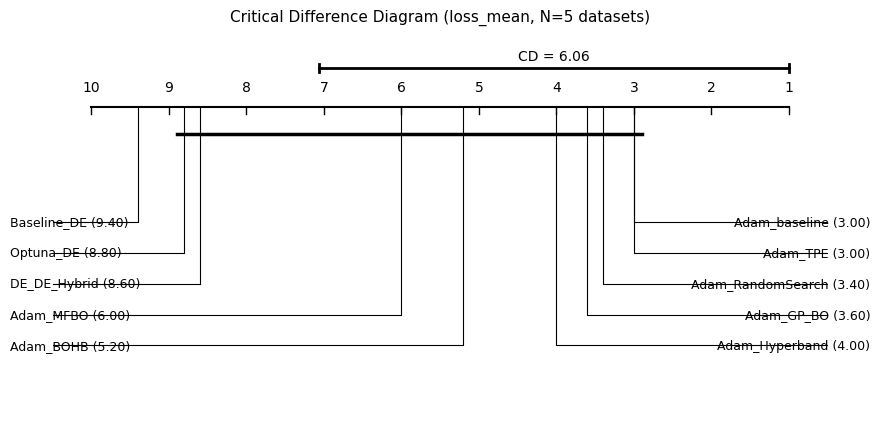

In [15]:
SMALL = ['wine', 'wdbc', 'digits', 'abalone', 'kin8nm']
df_small = df[df["dataset"].isin(SMALL)]
print(f"Малые датасеты: {len(df_small)} строк, методов: {df_small['method'].nunique()}")
results_small = run_full_statistical_analysis(df_small, metric="loss_mean", lower_is_better=True)

## 11. Critical Difference Diagram — только большие датасеты

Higgs + Fashion-MNIST. CD на двух датасетах нужно интерпретировать как
**иллюстрацию** ранжирования методов, а не как полноценный статистический
тест (Friedman требует ≥3 датасета для нормальной статистической мощности).

In [16]:
BIG = ['higgs', 'fashion_mnist']
df_big = df[df["dataset"].isin(BIG)]
print(f"Большие датасеты: {len(df_big)} строк")
results_big = run_full_statistical_analysis(df_big, metric="loss_mean", lower_is_better=True)

Большие датасеты: 7 строк
Недостаточно данных для Friedman: 1 датасетов, 7 методов. Нужно ≥3 датасета и ≥2 метода.


## 12. Группировка по типам датасетов

### 12a. Только классификация

In [17]:
CLASSIFICATION = ['wine', 'wdbc', 'digits', 'higgs', 'fashion_mnist']
df_clf = df[df["dataset"].isin(CLASSIFICATION)]
print(f"Классификация: {len(df_clf)} строк")
print_table(df_clf)

Классификация: 37 строк

=== Test Loss (mean ± std по seeds) ===
╒═══════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│ Dataset   │ Adam_baseline          │ Adam_TPE               │ Adam_RandomSearch      │ Optuna_DE              │ DE_DE_Hybrid           │ Adam_GP_BO             │ Adam_Hyperband         │ Adam_BOHB              │ Adam_MFBO              │ Baseline_DE            │
╞═══════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ WINE      │ 0.0786 ± 0.0804  (n=5) │ 0.1324 ± 0.0879  (n=5) │ 0.1050 ± 0.1625  (n=5) │ 1.3076 ± 1.3913  (n=5) │ 1.2679 ± 1.1488  (n=5) │ 0.16

### 12b. Только регрессия

In [18]:
REGRESSION = ['abalone', 'kin8nm']
df_reg = df[df["dataset"].isin(REGRESSION)]
print(f"Регрессия: {len(df_reg)} строк")
print_table(df_reg)

Регрессия: 20 строк

=== Test Loss (mean ± std по seeds) ===
╒═══════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│ Dataset   │ Adam_MFBO              │ Adam_BOHB              │ Adam_GP_BO             │ Adam_Hyperband         │ Adam_RandomSearch      │ Adam_baseline          │ Adam_TPE               │ DE_DE_Hybrid           │ Optuna_DE              │ Baseline_DE            │
╞═══════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ KIN8NM    │ 0.2262 ± 0.0835  (n=4) │ 0.1117 ± 0.0170  (n=4) │ 0.1041 ± 0.0027  (n=4) │ 0.1131 ± 0.0096  (n=4) │ 0.1175 ± 0.0110  (n=5) │ 0.1081 ±

## 13. Тестовые метрики — таблица только secondary (accuracy / R²)

Для удобной вставки в текст диплома — отдельная таблица с accuracy
для классификации и R² для регрессии.

In [19]:
import pandas as pd
sec_table = df.pivot(index="dataset", columns="method", values="sec_mean")
# Округляем до 4 знаков для красоты
sec_table_rounded = sec_table.round(4)
print("=== Test Accuracy / R² (mean) ===")
print(sec_table_rounded.to_string())

=== Test Accuracy / R² (mean) ===
method   Adam_BOHB  Adam_GP_BO  Adam_Hyperband  Adam_MFBO  Adam_RandomSearch  Adam_TPE  Adam_baseline  Baseline_DE  DE_DE_Hybrid  Optuna_DE
dataset                                                                                                                                    
abalone     0.5572      0.5675          0.5659     0.5003             0.5644    0.5652         0.5601       0.4621        0.5049     0.4892
digits      0.9741      0.9756          0.9756     0.9615             0.9770    0.9756         0.9815       0.7141        0.4015     0.7067
higgs       0.7212      0.7132          0.7212     0.7099             0.7148    0.7157         0.7233          NaN           NaN        NaN
kin8nm      0.8870      0.8948          0.8857     0.7709             0.8820    0.8968         0.8913       0.5795        0.4530     0.5924
wdbc        0.9651      0.9628          0.9721     0.9651             0.9698    0.9698         0.9744       0.9349        0.91

## 14. Wall-clock (только) — таблица для текста

Иногда нужно отдельно: «MFBO в N раз быстрее BOHB при сопоставимом качестве».

In [20]:
if 'time_mean' in df.columns:
    wc_table = df.pivot(index="dataset", columns="method", values="time_mean").round(1)
    print("=== Wall-clock seconds (mean) ===")
    print(wc_table.to_string())
else:
    print("Wall-clock данные доступны только в новом формате trajectory.json")

=== Wall-clock seconds (mean) ===
method   Adam_BOHB  Adam_GP_BO  Adam_Hyperband  Adam_MFBO  Adam_RandomSearch  Adam_TPE  Adam_baseline  Baseline_DE  DE_DE_Hybrid  Optuna_DE
dataset                                                                                                                                    
abalone       41.8        29.7            43.1       19.3               22.5      26.3            7.2          NaN           NaN        NaN
digits        19.9        13.1            18.7       12.7                9.2      10.4            3.0          NaN           NaN        NaN
higgs        464.0       179.3           496.4      160.7              178.0     178.9           49.9          NaN           NaN        NaN
kin8nm        84.0        48.5            69.4       67.7               40.3       NaN           14.2          NaN           NaN        NaN
wdbc           5.8         6.7             6.5        7.1                3.1       3.0            1.1         33.2       16649

## 15. Сравнение MFBO vs BOHB по wall-clock — для тезиса диплома

Один из ключевых тезисов: «MFBO достигает того же качества за меньшее
wall-clock». Здесь явное численное сравнение.

In [21]:
if 'time_mean' in df.columns:
    cmp = df[df['method'].isin(['Adam_MFBO', 'Adam_BOHB', 'Adam_Hyperband', 'Adam_TPE'])].copy()
    cmp_wide = cmp.pivot(index="dataset", columns="method",
                          values=["loss_mean", "time_mean"])
    print("=== MFBO vs BOHB / Hyperband / TPE ===")
    print(cmp_wide.round(2).to_string())
else:
    print("(data unavailable)")

=== MFBO vs BOHB / Hyperband / TPE ===
        loss_mean                                   time_mean                                  
method  Adam_BOHB Adam_Hyperband Adam_MFBO Adam_TPE Adam_BOHB Adam_Hyperband Adam_MFBO Adam_TPE
dataset                                                                                        
abalone      0.44           0.43      0.49     0.43     41.85          43.06     19.28    26.32
digits       0.20           0.16      0.22     0.20     19.90          18.71     12.70    10.36
higgs        0.54           0.54      0.56     0.57    464.03         496.43    160.72   178.92
kin8nm       0.11           0.11      0.23     0.10     84.02          69.40     67.67      NaN
wdbc         0.16           0.12      0.12     0.12      5.81           6.53      7.13     3.02
wine         0.16           0.22      0.16     0.13      1.97           2.17      5.42     1.43


## 16. Сохранённые файлы

После выполнения этого ноутбука в `results_fixed/` появятся:
- `bar_comparison.png`
- `convergence_time.png`, `convergence_n_evals_full.png`, `convergence_n_epochs_eq.png`
- `convergence_time_all.png`, `convergence_epochs_all.png`
- `cd_diagram_loss_mean.png` (последний вызов перезаписывает предыдущий)

Если хотите сохранить разные CD-диаграммы — переименуйте файлы вручную
после каждого `run_full_statistical_analysis` или передавайте `save_dir=...`

In [22]:
import os
from src.config import RESULTS_DIR
artifacts = [f for f in os.listdir(RESULTS_DIR) if f.endswith('.png')]
print(f"PNG-файлов в {RESULTS_DIR}: {len(artifacts)}")
for f in sorted(artifacts):
    path = os.path.join(RESULTS_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f} ({size_kb:.0f} KB)")

PNG-файлов в results_fixed: 9
  bar_comparison.png (92 KB)
  cd_diagram_loss_mean.png (49 KB)
  convergence.png (581 KB)
  convergence_epochs_all.png (545 KB)
  convergence_n_epochs_eq.png (545 KB)
  convergence_n_evals_full.png (291 KB)
  convergence_time.png (484 KB)
  convergence_time_all.png (484 KB)
  small_datasets_wall_clock.png (130 KB)
